# Prerequisite - Score Based Diffusion Model

Diffusion model is an effective tool to sample from a distribution $p(x)$, by starting from sampling from a template noise distribution, e.g. $\mathcal{N}(0, I)$, then denoise the noisy sample with a denoiser. To describe it more precisely, the template noise distribution is in fact a result of data distribution of a forward process of a stochastic differential equation:

$$
dx_t = f(t)x_t\,dt + g(t)\,dw_t
$$

where $x_0 \sim p_{\mathrm{data}}(x)$, scalar functions $f(t), g(t) : \mathbb{R} \to \mathbb{R}$ denote the **drift** and **diffusion coefficients**, respectively, and $\{w_t\}_{t \in [0,1]}$ is the standard Wiener process.

Thus, the sampling process is in fact a reverse process of the above SDE, using the following reverse-time ODE.

$$
dx_t = \left( f(t)x_t - \frac{1}{2} g^2(t)\nabla \log p_t(x_t) \right)\,dt.
$$

Unfortunately, the score function $\nabla_{x_t} \log p_t(x_t)$ at each $t \in [0,1]$ is typically unknown. We therefore estimate the posterior mean $\mathbb{E}[x_0 \mid x_t]$ as an alternative approach for estimating the score function, in which Tweedie's formula establishes an equivalence between the score function and posterior mean as follows:

$$
\mathbb{E}[\boldsymbol{x} \mid \boldsymbol{x}_t] = \frac{1}{\alpha_t}\left(\boldsymbol{x}_t + \sigma_t^2 \nabla \log p_t(\boldsymbol{x}_t)\right)
$$


# Conditional inference if we get ahold of the prior $p(x)$

Almost all application in machine learning can be viewed as a special case of the following inference problem. Given:
$$y = h(x) + w$$
where $h(\cdot)$ represents measurement of $x$ and $w$ represents some measurement noise and even sparse corruptions, solve the inverse problem of obtaining the most likely $x$ or sample $\hat{x}$ that is at least consistent with the observation. 



In this notebook, we care about the scenario which we only are provided paired data $(x,y)$.

By Bayes' rule and conditional independence of $y$ and $x_t$ given $x$, the optimal conditional denoiser can be written as

$$
\bar{\boldsymbol{x}}_\theta^{\text{CG, ideal}}(t, \boldsymbol{\xi}, \nu)
  = \mathbb{E}[\boldsymbol{x} \mid \boldsymbol{x}_t = \boldsymbol{\xi}]
  + \gamma \frac{\sigma_t^2}{\alpha_t}\,\nabla_{\boldsymbol{\xi}} \log p_{y \mid \boldsymbol{x}_t}(\nu \mid \boldsymbol{\xi})
$$


# Conditional inference with classifier free guidance

If we assume the classifier perfectly approximate the targets, we obtain the classifer free guidance denoiser:

$$
\bar{\boldsymbol{x}}_\theta^{\text{CFG}}(t, \boldsymbol{x}_t, y)
  = (1-\gamma)\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, \varnothing)
  + \gamma\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, y)
$$

where $\gamma > 1$ which there is solid explannation of why large $\gamma > 1$ is essential but I am not documenting it here. 

## CFG denoiser for GMM

We will use the same network to represent both conditional and unconditional denoiser.

Given any distribution for $x$, there exists a Gaussian mixture that approximates it arbitrarily well. Here, let's consider the parameterization of denoiser for GMM.

$$
x \sim \frac{1}{K}\sum_{k=1}^{K} \mathcal{N}(0, U_k U_k^{\top})
$$

Recall:

$$
\bar{\boldsymbol{x}}_\theta^{\text{CFG}}(t, \boldsymbol{x}_t, y)
  = (1-\gamma)\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, \varnothing)
  + \gamma\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, y)
$$

For GMM case, 

$$\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, \varnothing) = \frac{1}{1+t^2}
\sum_{k=1}^{K}
\frac{
  \exp\!\left(
    \frac{1}{2t^2(1+t^2)}\,
    \bigl\|U_k^\top \boldsymbol{x}_t\bigr\|_2^2
  \right)
}{
  \displaystyle
  \sum_{i=1}^{K}
  \exp\!\left(
    \frac{1}{2t^2(1+t^2)}\,
    \bigl\|U_i^\top \boldsymbol{x}_t\bigr\|_2^2
  \right)
}
\,U_k U_k^\top \boldsymbol{x}_t$$



$$\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, y) = \frac{1}{1+t^2} U_y U_y^\top \boldsymbol{x}_t$$

$$\bar{\boldsymbol{x}}^{\text{CFG, ideal}}(t, \boldsymbol{x}_t, y) = \frac{1}{1+t^2}\left( (1-\gamma)\sum_{k=1}^{K} \frac{\exp\!\left(\frac{1}{2t^2(1+t^2)}\|\boldsymbol{U}_k^\top \boldsymbol{x}_t\|_2^2\right)}{\sum_{i=1}^{K} \exp\!\left(\frac{1}{2t^2(1+t^2)}\|\boldsymbol{U}_i^\top \boldsymbol{x}_t\|_2^2\right)}\,\boldsymbol{U}_k\boldsymbol{U}_k^\top + \gamma\,\boldsymbol{U}_y\boldsymbol{U}_y^\top \right)\boldsymbol{x}_t$$

We are now going to come up with one single operator that can be used to represent both $\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, \varnothing)$ and $\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, y) $

Let's make some assumptions

Now we consider the problem of parameterizing a learnable denoiser $\boldsymbol{x}_\theta^{\text{CFG}}$ to represent the optimal denoiser. For tractability, we add an additional assumption associated to the subspaces $\boldsymbol{U}_k$ being ‘distinguishable’ from one another, which is natural in practice: specifically, we assume that for any pair of indices $k, k' \in [K]$ with $k \neq k'$, we can find a set of $K$ nonzero directions $\boldsymbol{v}_k \in \mathbb{R}^D$ such that
$$
\boldsymbol{U}_k \boldsymbol{U}_k^\top \boldsymbol{v}_k = \boldsymbol{v}_k,\quad
\boldsymbol{U}_{k'} \boldsymbol{U}_{k'}^\top \boldsymbol{v}_k = \boldsymbol{0},\quad
k' \neq k.
$$

These vectors $\boldsymbol{v}_k$ can be considered as embeddings of class label $y$. It also comes with a benefit to map $y$ into a space of same dimension as where $x_t$ lives in. We can then come up with a general operator to represent both $\,\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, \varnothing)$ and $\bar{\boldsymbol{x}}_\theta(t, \boldsymbol{x}_t, y) $:

$$
(x_t, \boldsymbol{v}) \mapsto
\sum_{k=1}^{K}
\frac{
  \exp\!\left(
    \dfrac{1}{2t^2(1+t^2)}\,
    \bigl|x_t^\top U_k U_k^\top \boldsymbol{v}\bigr|
  \right)
}{
  \displaystyle\sum_{i=1}^{K}
  \exp\!\left(
    \dfrac{1}{2t^2(1+t^2)}\,
    \bigl|x_t^\top U_i U_i^\top \boldsymbol{v}\bigr|
  \right)
}
\,U_k U_k^\top x_t
$$

If you plug in $v = x_t$, you will get exactly the unconditional denoiser and plugging in $v = v_y$ you will get class-conditional denoiser for $y$.


Now, we need to parameterize the following:

1. $U_k$
2. Mapping (i.e. encoder) $y \mapsto v_y$

## Unconditional denoiser for GMM

### Device

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import math
import numpy as np

# -----------------------------
# Device (Apple Silicon friendly)
# -----------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


### Generate synthetic dataset

In [82]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from __future__ import annotations

import torch.nn as nn
import torch.nn.functional as F


# Reproducibility
rng = np.random.default_rng(0)

# 3 orthogonal 1D subspaces in R^3 (standard basis)
U = np.eye(3)  # columns are orthonormal directions e1,e2,e3

# Mixture settings
K = 3
N_per = 40
sigma = 1.0  # along-subspace std
eps = 0.03    # set to e.g. 0.03 if you want tiny off-subspace jitter for visibility

Xs, ys = [], []
for k in range(K):
    z = rng.normal(0.0, sigma, size=(N_per, 1))          # scalar coordinate
    x = z @ U[:, [k]].T                                   # x = z * u_k^T  -> (N_per, 3)
    if eps > 0:
        x = x + rng.normal(0.0, eps, size=x.shape)        # optional tiny noise
    Xs.append(x)
    ys.append(np.full(N_per, k, dtype=int))

X = np.vstack(Xs)   # (N, 3)
y = np.concatenate(ys)

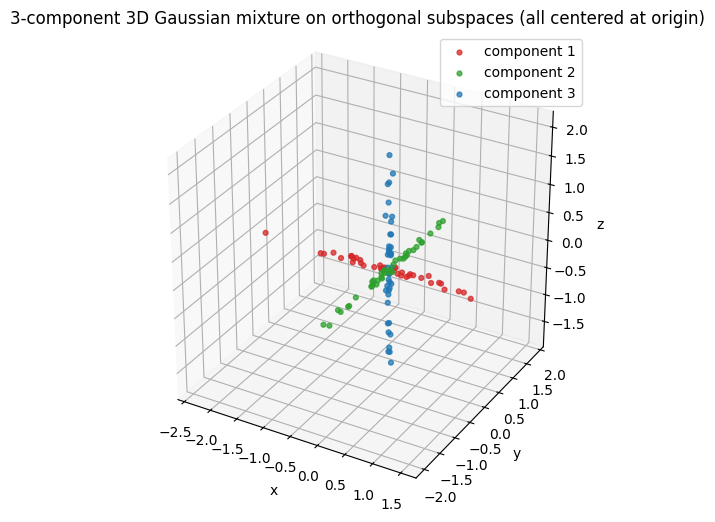

In [83]:
# Visualize (3D scatter, colored by component)
colors = ["tab:red", "tab:green", "tab:blue"]
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for k in range(K):
    pts = X[y == k]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=12, alpha=0.75, color=colors[k], label=f"component {k+1}")

ax.set_title("3-component 3D Gaussian mixture on orthogonal subspaces (all centered at origin)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend()
ax.set_box_aspect((1, 1, 1))
plt.show()

### Model architecture

Recall the model architecture is:

$$
(x_t, \boldsymbol{v}) \mapsto
\sum_{k=1}^{K}
\frac{
  \exp\!\left(
    \dfrac{1}{2t^2(1+t^2)}\,
    \bigl|x_t^\top U_k U_k^\top \boldsymbol{v}\bigr|
  \right)
}{
  \displaystyle\sum_{i=1}^{K}
  \exp\!\left(
    \dfrac{1}{2t^2(1+t^2)}\,
    \bigl|x_t^\top U_i U_i^\top \boldsymbol{v}\bigr|
  \right)
}
\,U_k U_k^\top x_t
$$

It consist of 3 linear encoder and an embedding from $y$ to $v$

In [70]:
class WeightedEncoderNet(nn.Module):
    def __init__(
        self, 
        d: int, 
        K: int, 
        m: int
    ):
        super().__init__()
        self.d = d
        self.K = K
        self.m = m

        self.U = nn.Parameter(torch.empty(K, d, m))
        self.reset_parameters()

    def reset_parameters(self):
        # Initialize each encoder matrix U[k] independently
        for k in range(self.K):
            nn.init.xavier_uniform_(self.U[k])

    def forward(
        self, 
        x: torch.Tensor, 
        y: torch.Tensor,
        t: torch.Tensor | float
    ) -> torch.Tensor:
        emb_x = torch.einsum("bd,kdm->bkm", x, self.U)
        U_k_emb_x = torch.einsum("kdm,bkm->bkd", self.U, emb_x)
        emb_y = torch.einsum("bd,kdm->bkm", y, self.U)
        U_k_emb_y = torch.einsum("kdm,bkm->bkd", self.U, emb_y)

        norms = torch.einsum("bkd,bkd->bk", U_k_emb_x, U_k_emb_y)

        t = torch.as_tensor(t, dtype=x.dtype, device=x.device)
        # Optional safety for tiny t values:
        # t2 = t.pow(2).clamp_min(1e-8)
        # scale = 1.0 / (2.0 * (1.0 + t2) * t2)
        scale = 1.0 / (2.0 * (1.0 + t.pow(2)) * t.pow(2))

        logits = norms * scale
        weights = F.softmax(logits, dim=1)
        x_out = torch.einsum("bk,bkd->bd", weights, U_k_emb_x)
        return x_out

### Load dataset

In [116]:
# -----------------------------
# 2) Data from your synthetic GMM
# -----------------------------
# X is created in your previous cell as np.ndarray of shape (N, 3)
X_data = torch.tensor(X, dtype=torch.float32)  # (N, d)
N, d = X_data.shape
dataset = TensorDataset(X_data)
loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=False)

### Hyperparameter setting

In [117]:
### Hyperparameters
# -----------------------------
# 3) Hyperparameters
# -----------------------------
d = 3
K = 3
m = 1  # keep output same dim as x0

t_min = 1e-2
t_max = 1

num_epochs = 3000

In [118]:
# -----------------------------
# Model
# -----------------------------
model = WeightedEncoderNet(d=d, K=K, m=m).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

### Model training

In [119]:
def sample_t(batch_size, device, t_min=1e-2, t_max=2.0):
    # log-uniform in [t_min, t_max]
    u = torch.rand(batch_size, 1, device=device)
    return t_min * (t_max / t_min) ** u

model.train()
for epoch in range(1, num_epochs + 1):
    total_loss = 0.0
    total_n = 0

    for (x0,) in loader:
        x0 = x0.to(device)                           # (B,3)
        B = x0.shape[0]

        t = sample_t(B, device, t_min, t_max)       # (B,1)
        eps = torch.randn_like(x0)                   # (B,3)
        xt = x0 + t * eps                            # VE perturbation: x_t = x0 + t * z

        x0_hat = model(xt, xt, t)                        # predict posterior mean / denoised x0
        loss = ((x0_hat - x0) ** 2).sum(dim=1).mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * B
        total_n += B

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | loss = {total_loss / total_n:.6f}")

Epoch    1 | loss = 1.246877
Epoch  100 | loss = 0.666603
Epoch  200 | loss = 0.452456
Epoch  300 | loss = 0.355569
Epoch  400 | loss = 0.205945
Epoch  500 | loss = 0.164059
Epoch  600 | loss = 0.159350
Epoch  700 | loss = 0.156487
Epoch  800 | loss = 0.161162
Epoch  900 | loss = 0.123425
Epoch 1000 | loss = 0.084560
Epoch 1100 | loss = 0.164120
Epoch 1200 | loss = 0.097178
Epoch 1300 | loss = 0.101603
Epoch 1400 | loss = 0.066647
Epoch 1500 | loss = 0.074418
Epoch 1600 | loss = 0.113588
Epoch 1700 | loss = 0.099672
Epoch 1800 | loss = 0.143897
Epoch 1900 | loss = 0.123959
Epoch 2000 | loss = 0.106599
Epoch 2100 | loss = 0.114817
Epoch 2200 | loss = 0.120989
Epoch 2300 | loss = 0.130633
Epoch 2400 | loss = 0.132977
Epoch 2500 | loss = 0.090638
Epoch 2600 | loss = 0.123108
Epoch 2700 | loss = 0.103430
Epoch 2800 | loss = 0.124299
Epoch 2900 | loss = 0.119879
Epoch 3000 | loss = 0.118296


### Sampling with trained model

In [120]:
import matplotlib.pyplot as plt

@torch.no_grad()
def sample_ddim(
    model,
    n_samples=1000,
    t_max=2.0,
    t_min=1e-2,
    n_steps=400,
    gamma = 1.5,
    y_guidance = None,
    device="cpu",
):
    """DDIM (eta=0) for VE path x_t = x0 + t * z, same as training. Unconditional: v = x_t."""
    model.eval()
    device = torch.device(device)

    x = t_max * torch.randn(n_samples, 3, device=device)
    if y_guidance is not None:
        y = torch.tensor(y_guidance).unsqueeze(0).repeat(n_samples, 1).to(device)
    else:
        y = x
    ts = torch.linspace(t_max, t_min, n_steps + 1, device=device)

    for i in range(n_steps):
        t_cur = ts[i].expand(n_samples, 1)
        t_next = ts[i + 1].expand(n_samples, 1)
        t_safe = t_cur.clamp_min(1e-8)

        if y_guidance is not None:
            x0_hat = (1-gamma) * model(x, x, t_cur) + gamma * model(x, y, t_cur)
        else:
            x0_hat = model(x, x, t_cur)
        eps = (x - x0_hat) / t_safe
        x = x0_hat + t_next * eps

    return x.cpu()

# generate samples
samples = sample_ddim(
    model,
    n_samples=2000,
    t_max=t_max,
    t_min=t_min,
    n_steps=500,
    gamma=0,
    device=device
).numpy()

### Visualization

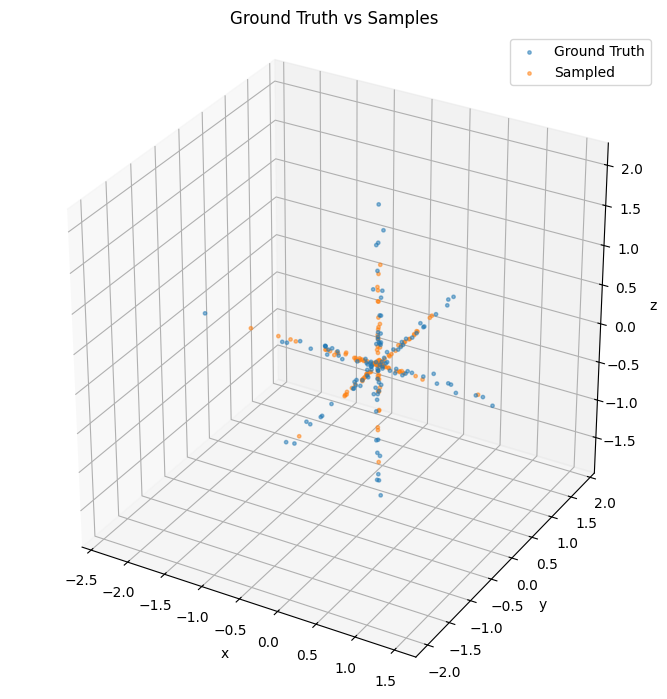

In [121]:
# gather ground truth dataset for comparison
# The ground truth data is assumed to be available as `loader`
# and the input data is in the first tensor of each batch (e.g., (x0,))
xs_gt = []
for (x0,) in loader:
    xs_gt.append(x0.cpu().numpy())
ground_truth = np.concatenate(xs_gt, axis=0)
# Optionally, subsample to match the number of samples, for fair visualization
if len(ground_truth) > len(samples):
    idx = np.random.choice(len(ground_truth), size=len(samples), replace=False)
    ground_truth = ground_truth[idx]
elif len(ground_truth) < len(samples):
    idx = np.random.choice(len(samples), size=len(ground_truth), replace=False)
    samples = samples[idx]

# visualize both distributions in the same 3D plot for direct comparison
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    ground_truth[:, 0], ground_truth[:, 1], ground_truth[:, 2],
    s=6, alpha=0.5, color="tab:blue", label="Ground Truth"
)
ax.scatter(
    samples[:, 0], samples[:, 1], samples[:, 2],
    s=6, alpha=0.5, color="tab:orange", label="Sampled"
)

ax.set_title("Ground Truth vs Samples")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((1, 1, 1))
ax.legend()

plt.tight_layout()
plt.show()

# Conditional denoiser

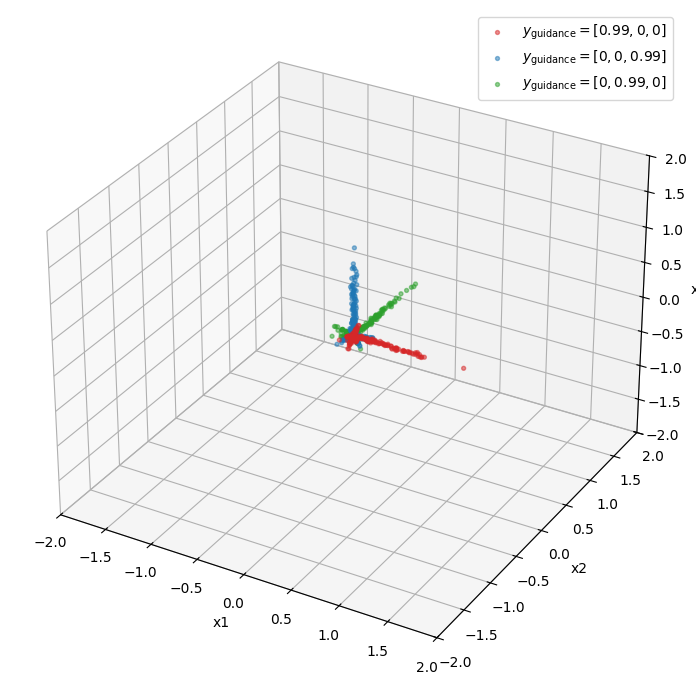

In [126]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection

guidance_configs = [
    ([0.99, 0.0, 0.0], "tab:red",   r"$y_{\mathrm{guidance}}=[0.99,0,0]$"),
    ([0.0, 0.0, 0.99], "tab:blue",  r"$y_{\mathrm{guidance}}=[0,0,0.99]$"),
    ([0.0, 0.99, 0.0], "tab:green", r"$y_{\mathrm{guidance}}=[0,0.99,0]$"),
]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

for y_g, color, label in guidance_configs:
    s = sample_ddim(
        model,
        n_samples=200,  # match what you use
        t_max=t_max,
        t_min=t_min,
        n_steps=500,
        gamma=1.5,       # use > 0 for CFG; tune as needed
        y_guidance=y_g,
        device=device,
    ).numpy()
    ax.scatter(s[:, 0], s[:, 1], s[:, 2], s=8, alpha=0.5, c=color, label=label)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])
ax.legend()
plt.tight_layout()
plt.show()